# 04 — Analyse SQL avec DuckDB

**Objectif :** Analyses métier avancées via SQL (DuckDB en mémoire sur DataFrame Pandas).  
**Requêtes :** KPIs, tendances, top zones, causes, analyses économiques, window functions.

---

In [ ]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import duckdb
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sql_queries import AccidentsDB, AccidentsQueries, export_sql_report
from utils import load_dataframe, GRAVITE_COLORS, PALETTE

TABLES_DIR = Path('../reports/tables')
FIGURES_DIR = Path('../reports/figures')
TABLES_DIR.mkdir(parents=True, exist_ok=True)

df = load_dataframe('../data/processed/accidents_clean.parquet')
db = AccidentsDB(df)
q  = AccidentsQueries(db)

print('DuckDB prêt ')

2026-05-21 19:28:11 | INFO     | utils | DataFrame chargé ← ..\data\processed\accidents_clean.parquet (49,783 lignes)
2026-05-21 19:28:11 | INFO     | sql_queries | DuckDB initialisé avec 49,783 accidents.


DuckDB prêt ✓


## 1. KPIs Globaux

In [2]:
kpis = q.kpi_globaux()
kpis = kpis.T
kpis.columns = ['Valeur']
kpis.index.name = 'Indicateur'
print('═' * 50)
print('KPIs GLOBAUX — Togo Road Accidents 2022-2025')
print('═' * 50)
display(kpis)

kpis.to_csv(TABLES_DIR / '04_kpis_globaux.csv', encoding='utf-8-sig')

══════════════════════════════════════════════════
KPIs GLOBAUX — Togo Road Accidents 2022-2025
══════════════════════════════════════════════════


,Valeur
Indicateur,
total_accidents,49783
total_deces,21112.0
total_victimes,109036.0
moy_victimes_par_accident,2.19
taux_mortalite_pct,42.41
cout_moyen_MFCFA,2.147
cout_total_GFCFA,106.861503
date_debut,2022-01-01 00:00:00
date_fin,2025-12-31 00:00:00


## 2. Distribution par Gravité

In [3]:
grav_df = q.repartition_par_gravite()
print(grav_df.to_string(index=False))
grav_df.to_csv(TABLES_DIR / '04_gravite.csv', index=False, encoding='utf-8-sig')

gravite  nb_accidents   pct  total_victimes  total_deces  cout_moyen_FCFA
 Mortel          9885 19.86         34640.0      19149.0        5223912.0
  Grave         13260 26.64         33790.0       1963.0        2252077.0
  Léger         26638 53.51         40606.0          0.0         952046.0


## 3. Analyse Temporelle

Évolution annuelle :
 annee  nb_accidents  deces  taux_mortalite  vitesse_moyenne  cout_total_MFCFA
  2022         12326 5301.0           43.01             64.4           26564.5
  2023         12544 5244.0           41.80             63.7           26743.8
  2024         12476 5254.0           42.11             64.6           26769.3
  2025         12437 5313.0           42.72             64.5           26783.9


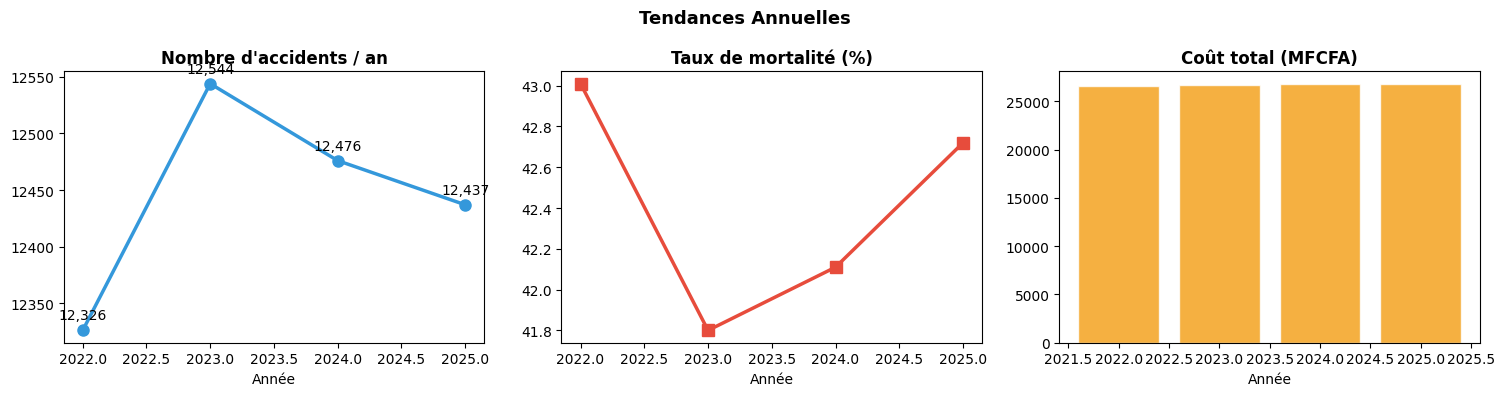

In [4]:
# Tendance annuelle
annual = q.tendance_annuelle()
print('Évolution annuelle :')
print(annual.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(annual['annee'], annual['nb_accidents'], 'o-', color=PALETTE['secondary'], linewidth=2.5, markersize=8)
axes[0].set_title('Nombre d\'accidents / an', fontweight='bold')
axes[0].set_xlabel('Année')
for x, y in zip(annual['annee'], annual['nb_accidents']):
    axes[0].annotate(f'{y:,}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center')

axes[1].plot(annual['annee'], annual['taux_mortalite'], 's-', color=PALETTE['danger'], linewidth=2.5, markersize=8)
axes[1].set_title('Taux de mortalité (%)', fontweight='bold')
axes[1].set_xlabel('Année')

axes[2].bar(annual['annee'], annual['cout_total_MFCFA'], color=PALETTE['warning'], alpha=0.8, edgecolor='white')
axes[2].set_title('Coût total (MFCFA)', fontweight='bold')
axes[2].set_xlabel('Année')

plt.suptitle('Tendances Annuelles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_tendances_annuelles.png', dpi=150, bbox_inches='tight')
plt.show()

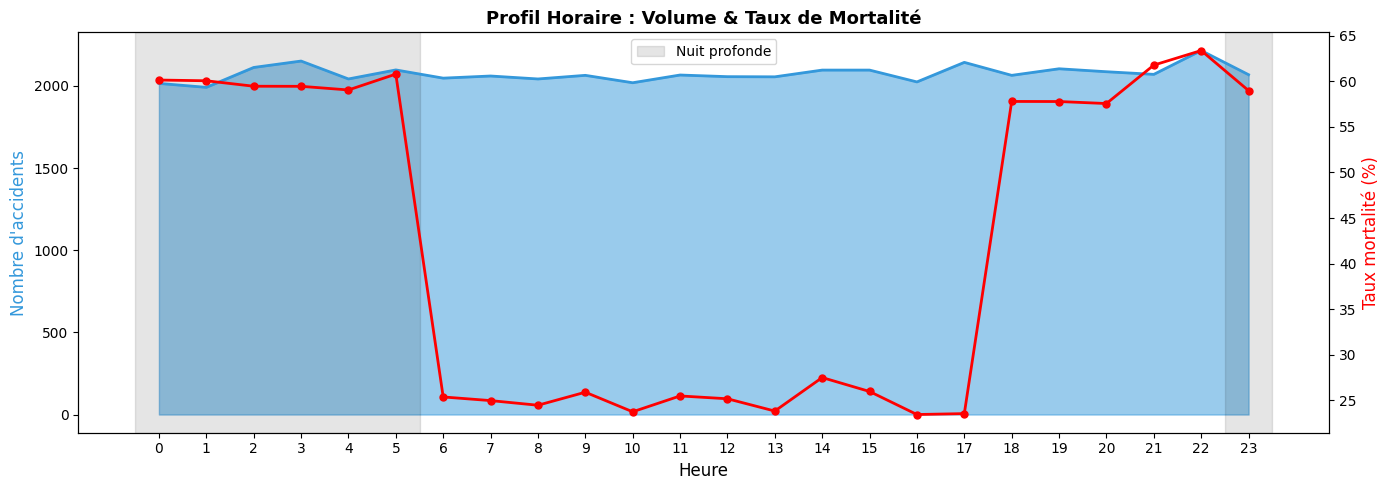

In [5]:
# Distribution par heure
hourly = q.accidents_par_heure()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.fill_between(hourly['heure'], hourly['nb_accidents'], alpha=0.5, color=PALETTE['secondary'])
ax1.plot(hourly['heure'], hourly['nb_accidents'], color=PALETTE['secondary'], linewidth=2)
ax1.set_xlabel('Heure', fontsize=12)
ax1.set_ylabel('Nombre d\'accidents', color=PALETTE['secondary'], fontsize=12)
ax1.set_xticks(range(24))

ax2 = ax1.twinx()
ax2.plot(hourly['heure'], hourly['taux_mortalite'], 'ro-', linewidth=2, markersize=5)
ax2.set_ylabel('Taux mortalité (%)', color='red', fontsize=12)

# Zones de risque
ax1.axvspan(22.5, 23.5, alpha=0.1, color='black')
ax1.axvspan(-0.5, 5.5, alpha=0.1, color='black', label='Nuit profonde')
ax1.legend()

plt.title('Profil Horaire : Volume & Taux de Mortalité', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_profil_horaire_sql.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Cumul glissant des décès
running = q.running_total_deces_par_annee()

fig = px.line(
    running, x='mois', y='deces_cumul', color='annee',
    title='Cumul des Décès par Mois (par année)',
    labels={'mois': 'Mois', 'deces_cumul': 'Décès cumulés', 'annee': 'Année'},
    markers=True
)
fig.update_layout(height=400)
fig.show()

## 4. Top Zones Dangereuses

TOP 5 RÉGIONS À RISQUE :


,region,nb_accidents,deces,victimes,taux_mortalite,vitesse_moy,cout_total_MFCFA,pct_accidents
0,Centrale,7343,3183.0,16034.0,43.35,64.6,16016.1,14.75
1,Kara,7508,3223.0,16508.0,42.93,65.0,16429.6,15.08
2,Plateaux,9823,4176.0,21537.0,42.51,64.0,20806.2,19.73
3,Maritime,17510,7405.0,38346.0,42.29,64.2,37714.2,35.17
4,Savanes,7599,3125.0,16611.0,41.12,63.8,15895.4,15.26



TOP 10 AXES ROUTIERS DANGEREUX :


,axe_routier,nb_accidents,deces,taux_mortalite,vitesse_moy,nb_villes_touchees
0,Lomé-Kara,8357,3617.0,43.28,64.5,12
1,Atakpamé-Sokodé,8443,3611.0,42.77,64.3,12
2,Lomé-Cotonou,8362,3560.0,42.57,64.0,12
3,Kara-Dapaong,8226,3511.0,42.68,64.5,12
4,Lomé-Kpalimé,8257,3416.0,41.37,64.1,12
5,Sokodé-Kara,8138,3397.0,41.74,64.3,12


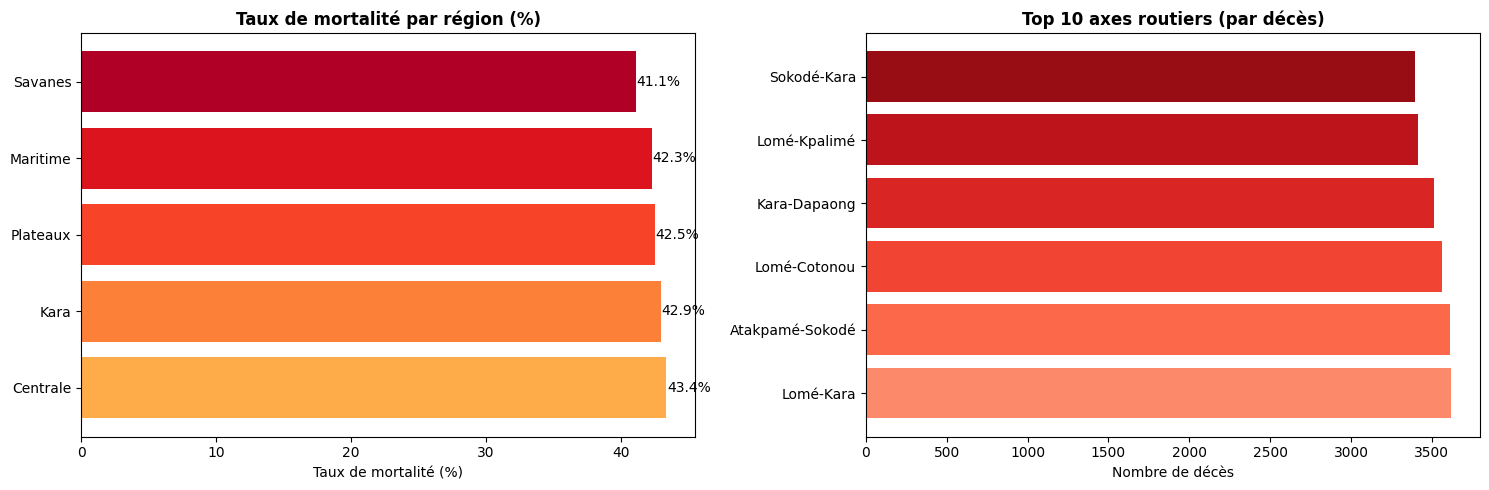

In [7]:
top_regions = q.top_regions_risque(n=5)
print('TOP 5 RÉGIONS À RISQUE :')
display(top_regions)

top_axes = q.top_axes_dangereux(n=10)
print('\nTOP 10 AXES ROUTIERS DANGEREUX :')
display(top_axes)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Régions
axes[0].barh(top_regions['region'], top_regions['taux_mortalite'],
             color=plt.cm.YlOrRd(np.linspace(0.4, 0.9, len(top_regions))))
axes[0].set_title('Taux de mortalité par région (%)', fontweight='bold')
axes[0].set_xlabel('Taux de mortalité (%)')
for i, (_, row) in enumerate(top_regions.iterrows()):
    axes[0].text(row['taux_mortalite'] + 0.05, i, f"{row['taux_mortalite']:.1f}%", va='center')

# Axes routiers
top10_axes = top_axes.head(10)
axes[1].barh(top10_axes['axe_routier'], top10_axes['deces'],
             color=plt.cm.Reds(np.linspace(0.4, 0.9, len(top10_axes))))
axes[1].set_title('Top 10 axes routiers (par décès)', fontweight='bold')
axes[1].set_xlabel('Nombre de décès')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_top_zones.png', dpi=150, bbox_inches='tight')
plt.show()

top_regions.to_csv(TABLES_DIR / '04_top_regions.csv', index=False, encoding='utf-8-sig')
top_axes.to_csv(TABLES_DIR / '04_top_axes.csv', index=False, encoding='utf-8-sig')

## 5. Analyse des Causes et de la Vitesse

In [8]:
vitesse_stats = q.analyse_vitesse()
print('Statistiques de vitesse par gravité et type de route :')
display(vitesse_stats)

# Corrélation excès vitesse × gravité
exces_grav = q.correlation_vitesse_gravite()
print('\nExcès de vitesse par niveau de gravité :')
display(exces_grav)

Statistiques de vitesse par gravité et type de route :


,gravite,type_route,vitesse_moy,vitesse_mediane,vitesse_std,exces_moy,limitation_moy,nb_accidents
0,Grave,Autoroute,100.7,98.0,17.3,-9.3,110.0,1319
1,Grave,Interurbaine,65.8,64.0,16.7,-4.2,70.0,1947
2,Grave,Nationale,84.3,84.0,16.2,-5.7,90.0,3831
3,Grave,Rurale,47.5,46.0,21.4,-2.5,50.0,2462
4,Grave,Urbaine,47.5,46.0,20.8,-2.5,50.0,3701
5,Léger,Autoroute,85.7,86.0,11.8,-24.3,110.0,455
6,Léger,Interurbaine,64.1,64.0,18.8,-5.9,70.0,4756
7,Léger,Nationale,76.6,75.0,16.7,-13.4,90.0,4658
8,Léger,Rurale,47.3,46.0,19.4,-2.7,50.0,6700
9,Léger,Urbaine,47.0,46.0,18.0,-3.0,50.0,10069



Excès de vitesse par niveau de gravité :


,gravite,exces_moy,q25,mediane,q75,p90,n
0,Mortel,-1.89,-10.0,-3.0,5.0,14.0,9885
1,Grave,-4.34,-14.0,-6.0,3.0,11.0,13260
2,Léger,-5.60,-15.0,-7.0,2.0,9.0,26638


In [9]:
# Pivot causes × gravité
try:
    pivot_causes = q.pivot_causes_gravite()
    print('Pivot causes × gravité :')
    display(pivot_causes)
    pivot_causes.to_csv(TABLES_DIR / '04_pivot_causes_gravite.csv', index=False, encoding='utf-8-sig')
except Exception as e:
    print(f'PIVOT non supporté dans cette version DuckDB : {e}')
    # Alternative
    pivot_causes = q.causes_par_gravite().pivot_table(
        index='cause', columns='gravite', values='nb_accidents', fill_value=0
    )
    display(pivot_causes)

Pivot causes × gravité :


,cause,Grave,Léger,Mortel
0,Excès de vitesse,2256.0,4228.0,1740.0
1,Alcool,1841.0,2789.0,1564.0
2,Fatigue,1815.0,2915.0,1533.0
3,Mauvais état route,1797.0,3826.0,1298.0
4,Défaillance mécanique,1750.0,3914.0,1270.0
5,Téléphone,1246.0,2895.0,750.0
6,Dépassement dangereux,795.0,1572.0,703.0
7,Sortie de route,946.0,2361.0,634.0
8,Inconnue,394.0,759.0,285.0
9,Collision piéton,420.0,1379.0,108.0


## 6. Analyse Économique

Coût par région :


,region,nb_accidents,cout_total_MFCFA,cout_moyen_FCFA,cout_max_FCFA,cout_median_FCFA
0,Maritime,17510,37714.2,2153865.0,20230612.0,1147821.0
1,Plateaux,9823,20806.2,2118111.0,20230612.0,1125058.0
2,Kara,7508,16429.6,2188277.0,20230612.0,1132737.0
3,Centrale,7343,16016.1,2181140.0,20230612.0,1169829.0
4,Savanes,7599,15895.4,2091780.0,20230612.0,1112718.0



Coût par cause :


,cause,nb_accidents,cout_total_MFCFA,cout_moyen,taux_mortalite
0,Excès de vitesse,8224,17207.26,2092322.0,44.11
1,Mauvais état route,6921,15186.38,2194247.0,40.82
2,Défaillance mécanique,6934,14923.42,2152210.0,39.04
3,Fatigue,6263,14860.06,2372674.0,51.78
4,Alcool,6194,14684.44,2370753.0,53.92
5,Téléphone,4891,9368.20,1915397.0,33.59
6,Sortie de route,3941,8058.06,2044674.0,34.94
7,Dépassement dangereux,3070,7154.44,2330438.0,48.40
8,Inconnue,1438,3072.52,2136664.0,41.03
9,Collision piéton,1907,2346.70,1230572.0,14.32


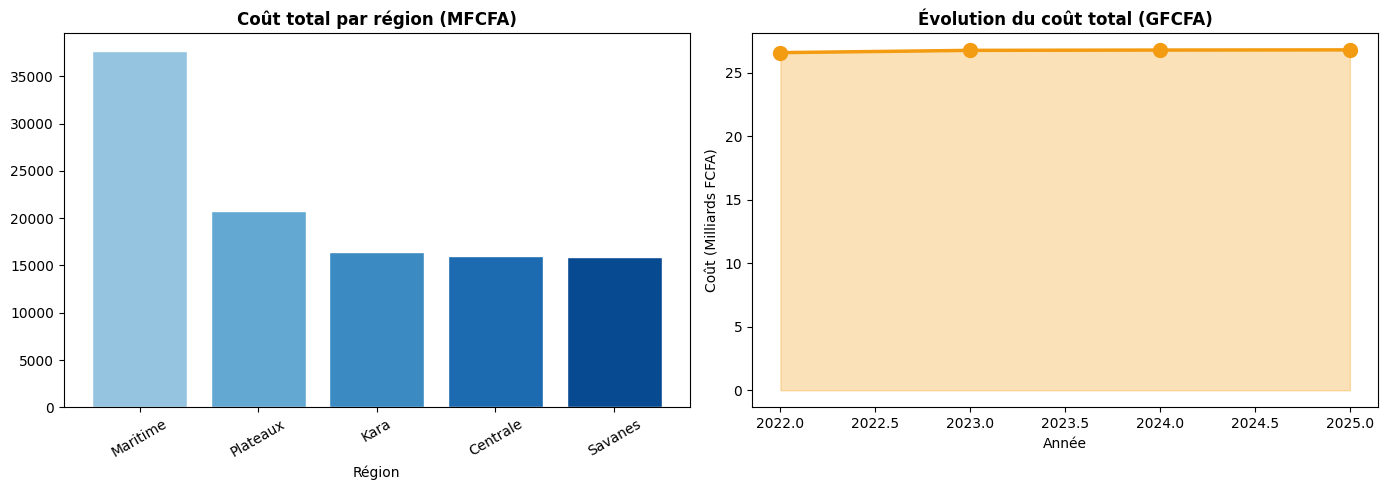

In [10]:
cout_region = q.cout_par_region()
cout_cause  = q.cout_par_cause()
cout_annuel = q.evolution_cout_annuel()

print('Coût par région :')
display(cout_region)

print('\nCoût par cause :')
display(cout_cause)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coût par région
axes[0].bar(cout_region['region'], cout_region['cout_total_MFCFA'],
            color=plt.cm.Blues(np.linspace(0.4, 0.9, len(cout_region))),
            edgecolor='white')
axes[0].set_title('Coût total par région (MFCFA)', fontweight='bold')
axes[0].set_xlabel('Région')
axes[0].tick_params(axis='x', rotation=30)

# Évolution coût annuel
axes[1].plot(cout_annuel['annee'], cout_annuel['cout_total_GFCFA'], 'o-',
             color=PALETTE['warning'], linewidth=2.5, markersize=10)
axes[1].fill_between(cout_annuel['annee'], cout_annuel['cout_total_GFCFA'],
                     alpha=0.3, color=PALETTE['warning'])
axes[1].set_title('Évolution du coût total (GFCFA)', fontweight='bold')
axes[1].set_xlabel('Année')
axes[1].set_ylabel('Coût (Milliards FCFA)')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_analyse_economique.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Export du rapport complet

In [ ]:
export_sql_report(df, TABLES_DIR)
db.close()

print('Rapport SQL exporté dans reports/tables/')
print('Prochaine étape : notebook 05_folium_map.ipynb')

2026-05-21 19:28:24 | INFO     | sql_queries | DuckDB initialisé avec 49,783 accidents.
2026-05-21 19:28:24 | INFO     | sql_queries |   Exporté : kpi_globaux.csv
2026-05-21 19:28:24 | INFO     | sql_queries |   Exporté : gravite.csv
2026-05-21 19:28:24 | INFO     | sql_queries |   Exporté : tendance_annuelle.csv
2026-05-21 19:28:24 | INFO     | sql_queries |   Exporté : accidents_par_heure.csv
2026-05-21 19:28:24 | INFO     | sql_queries |   Exporté : top_regions.csv
2026-05-21 19:28:24 | INFO     | sql_queries |   Exporté : top_axes.csv
2026-05-21 19:28:24 | INFO     | sql_queries |   Exporté : causes_gravite.csv
2026-05-21 19:28:24 | INFO     | sql_queries |   Exporté : analyse_vitesse.csv
2026-05-21 19:28:24 | INFO     | sql_queries |   Exporté : impact_epi.csv
2026-05-21 19:28:24 | INFO     | sql_queries |   Exporté : cout_region.csv
2026-05-21 19:28:24 | INFO     | sql_queries |   Exporté : risque_vehicule.csv
2026-05-21 19:28:24 | INFO     | sql_queries | Rapport SQL exporté dan

✓ Rapport SQL exporté dans reports/tables/
→ Prochaine étape : notebook 05_folium_map.ipynb
